In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ───────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

# ── Load cleaned data ──────────────────────────────────────
cleaned_path = r"D:\Projects\End-to-end projects\10. UPI Payments Intelligence\Data\Cleaned"

df = pd.read_csv(cleaned_path + r"\cleaned_transactions.csv", 
                 parse_dates=['txn_datetime', 'txn_date'])

user_agg    = pd.read_csv(cleaned_path + r"\user_aggregates.csv")
merchant_agg = pd.read_csv(cleaned_path + r"\merchant_aggregates.csv")
df_users    = pd.read_csv(cleaned_path + r"\cleaned_users.csv")
df_merchants = pd.read_csv(cleaned_path + r"\cleaned_merchants.csv")

print(f"✅ All data loaded")
print(f"Transactions: {len(df):,} rows x {df.shape[1]} columns")
print(f"Date range: {df['txn_date'].min().date()} to {df['txn_date'].max().date()}")

✅ All data loaded
Transactions: 500,000 rows x 39 columns
Date range: 2022-01-01 to 2023-12-31


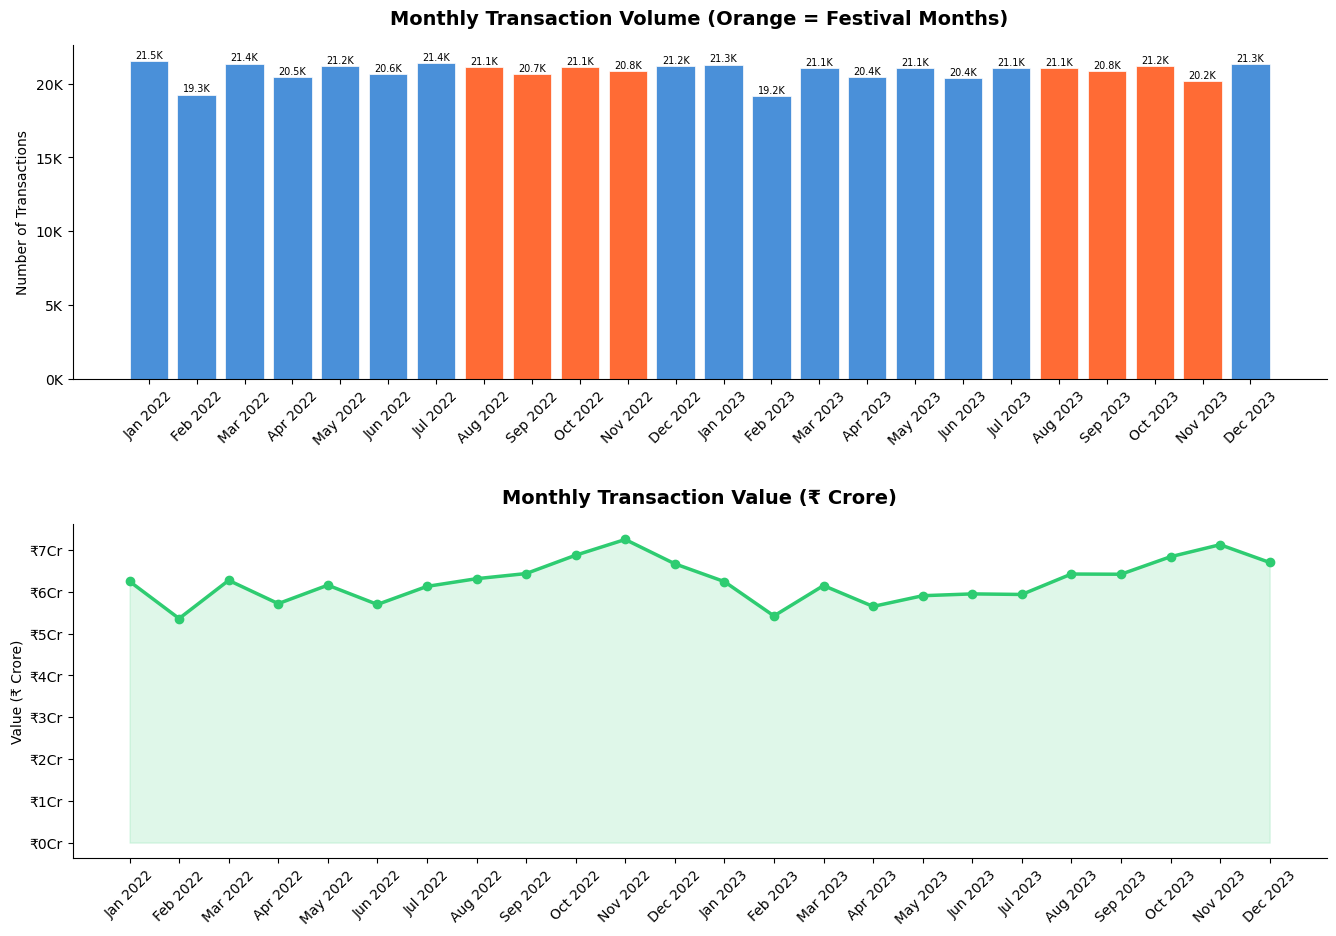

BUSINESS INSIGHT — MONTHLY TREND
Peak Month:         Jan 2022 (21,541 transactions)
Lowest Month:       Feb 2023 (19,177 transactions)
YoY Volume Growth:  -0.7% (2022 to 2023)
Festival Premium:   0.0% above average in Oct-Nov
2022 Total Value:   ₹75.1 Crore
2023 Total Value:   ₹74.8 Crore


In [4]:
# ── Define exports path ────────────────────────────────────
exports_path = r"D:\Projects\End-to-end projects\10. UPI Payments Intelligence\Exports"

# ── Monthly aggregation ────────────────────────────────────
monthly = df.groupby(['txn_year', 'txn_month']).agg(
    txn_count   = ('txn_id', 'count'),
    total_value = ('amount', 'sum'),
    avg_value   = ('amount', 'mean')
).reset_index()

monthly['period'] = pd.to_datetime(
    monthly['txn_year'].astype(str) + '-' + monthly['txn_month'].astype(str)
)
monthly = monthly.sort_values('period')
monthly['period_label'] = monthly['period'].dt.strftime('%b %Y')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Plot 1: Transaction Volume ─────────────────────────────
axes[0].bar(
    monthly['period_label'], 
    monthly['txn_count'],
    color=['#FF6B35' if m in [8,9,10,11] else '#4A90D9' for m in monthly['txn_month']],
    edgecolor='white', 
    linewidth=0.5
)
axes[0].set_title(
    'Monthly Transaction Volume (Orange = Festival Months)',
    fontsize=14, fontweight='bold', pad=15
)
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)
for i, v in enumerate(monthly['txn_count']):
    axes[0].text(i, v + 200, f'{v/1000:.1f}K', ha='center', fontsize=7)

# ── Plot 2: Total Transaction Value ───────────────────────
axes[1].plot(
    monthly['period_label'], 
    monthly['total_value']/1e7,
    marker='o', linewidth=2.5, color='#2ECC71', markersize=6
)
axes[1].fill_between(
    range(len(monthly)), 
    monthly['total_value']/1e7,
    alpha=0.15, color='#2ECC71'
)
axes[1].set_title(
    'Monthly Transaction Value (₹ Crore)',
    fontsize=14, fontweight='bold', pad=15
)
axes[1].set_ylabel('Value (₹ Crore)')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['period_label'], rotation=45)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}Cr')
)

plt.tight_layout(pad=3)
plt.savefig(exports_path + r"\01_monthly_trend.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Business Insight ───────────────────────────────────────
print("=" * 60)
print("BUSINESS INSIGHT — MONTHLY TREND")
print("=" * 60)

peak = monthly.loc[monthly['txn_count'].idxmax()]
low  = monthly.loc[monthly['txn_count'].idxmin()]

yoy_growth = (
    (monthly[monthly['txn_year']==2023]['txn_count'].sum() -
     monthly[monthly['txn_year']==2022]['txn_count'].sum()) /
     monthly[monthly['txn_year']==2022]['txn_count'].sum() * 100
)

festival_avg = monthly[monthly['txn_month'].isin([10,11])]['txn_count'].mean()
overall_avg  = monthly['txn_count'].mean()
festival_premium = (festival_avg / overall_avg - 1) * 100

print(f"Peak Month:         {peak['period_label']} ({peak['txn_count']:,} transactions)")
print(f"Lowest Month:       {low['period_label']} ({low['txn_count']:,} transactions)")
print(f"YoY Volume Growth:  {yoy_growth:.1f}% (2022 to 2023)")
print(f"Festival Premium:   {festival_premium:.1f}% above average in Oct-Nov")
print(f"2022 Total Value:   ₹{monthly[monthly['txn_year']==2022]['total_value'].sum()/1e7:.1f} Crore")
print(f"2023 Total Value:   ₹{monthly[monthly['txn_year']==2023]['total_value'].sum()/1e7:.1f} Crore")

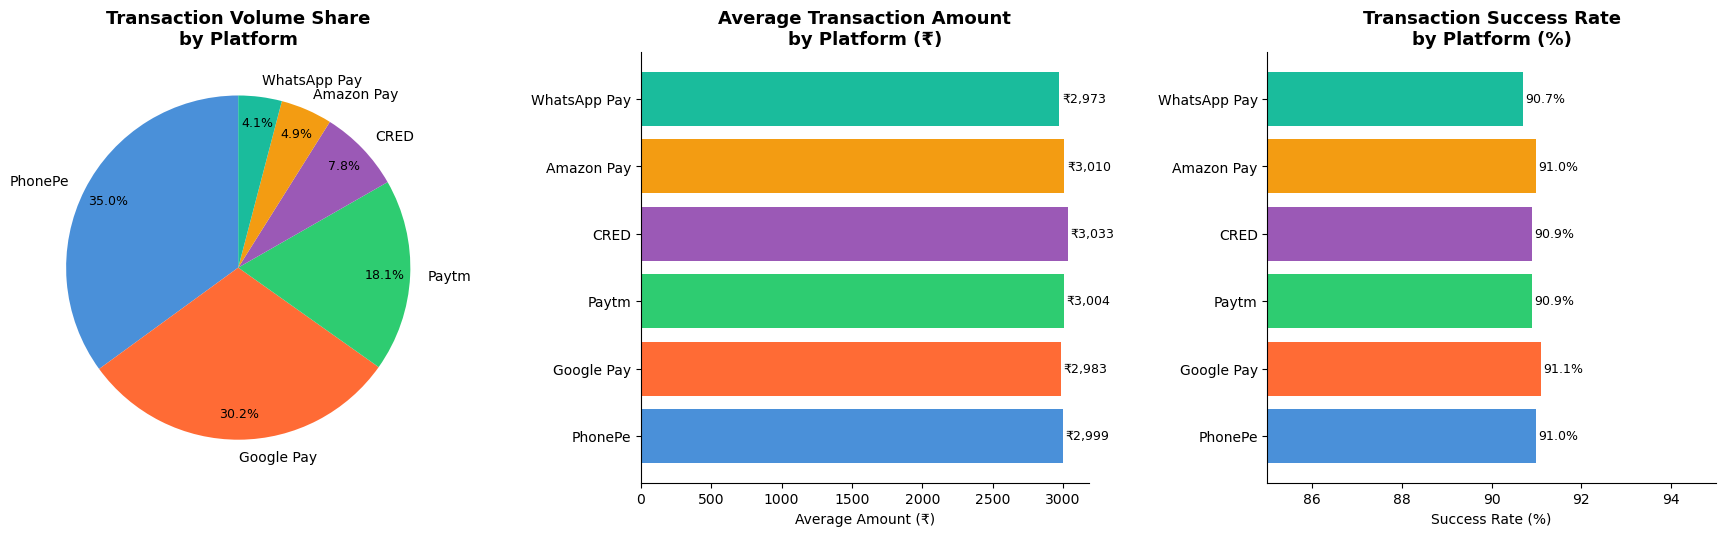

BUSINESS INSIGHT — PLATFORM ANALYSIS
Market Leader:         PhonePe with 35.0% volume share
Value Leader:          PhonePe with 35.0% value share
Highest Avg Ticket:    CRED at ₹3,033 per transaction
Lowest Success Rate:   WhatsApp Pay at 90.7%

Platform Summary:
platform_used  txn_share  value_share  avg_amount  success_rate
      PhonePe       35.0         35.0 2998.917232          91.0
   Google Pay       30.2         30.0 2983.372088          91.1
        Paytm       18.1         18.1 3004.011718          90.9
         CRED        7.8          7.9 3032.514840          90.9
   Amazon Pay        4.9          4.9 3010.326021          91.0
 WhatsApp Pay        4.1          4.0 2973.009790          90.7


In [5]:
# ── Platform transaction volume and value ──────────────────
platform = df.groupby('platform_used').agg(
    txn_count    = ('txn_id', 'count'),
    total_value  = ('amount', 'sum'),
    avg_amount   = ('amount', 'mean'),
    success_rate = ('is_success', 'mean'),
    fraud_rate   = ('is_fraud', 'mean')
).reset_index().sort_values('txn_count', ascending=False)

platform['txn_share']   = (platform['txn_count'] / platform['txn_count'].sum() * 100).round(1)
platform['value_share'] = (platform['total_value'] / platform['total_value'].sum() * 100).round(1)
platform['success_rate'] = (platform['success_rate'] * 100).round(1)
platform['fraud_rate']   = (platform['fraud_rate'] * 100).round(3)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Transaction Volume Share ──────────────────────
colors = ['#4A90D9', '#FF6B35', '#2ECC71', '#9B59B6', '#F39C12', '#1ABC9C']
wedges, texts, autotexts = axes[0].pie(
    platform['txn_count'],
    labels=platform['platform_used'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85
)
for text in autotexts:
    text.set_fontsize(9)
axes[0].set_title('Transaction Volume Share\nby Platform', 
                   fontsize=13, fontweight='bold')

# ── Plot 2: Avg Transaction Amount by Platform ────────────
bars = axes[1].barh(
    platform['platform_used'],
    platform['avg_amount'],
    color=colors
)
axes[1].set_title('Average Transaction Amount\nby Platform (₹)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Amount (₹)')
for bar, val in zip(bars, platform['avg_amount']):
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f'₹{val:,.0f}', va='center', fontsize=9)

# ── Plot 3: Success Rate by Platform ─────────────────────
bars2 = axes[2].barh(
    platform['platform_used'],
    platform['success_rate'],
    color=colors
)
axes[2].set_title('Transaction Success Rate\nby Platform (%)', 
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Success Rate (%)')
axes[2].set_xlim(85, 95)
for bar, val in zip(bars2, platform['success_rate']):
    axes[2].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=9)

plt.tight_layout(pad=3)
plt.savefig(exports_path + r"\02_platform_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Business Insight ───────────────────────────────────────
print("=" * 60)
print("BUSINESS INSIGHT — PLATFORM ANALYSIS")
print("=" * 60)
top = platform.iloc[0]
bottom = platform.iloc[-1]
highest_avg = platform.loc[platform['avg_amount'].idxmax()]
lowest_success = platform.loc[platform['success_rate'].idxmin()]

print(f"Market Leader:         {top['platform_used']} with {top['txn_share']}% volume share")
print(f"Value Leader:          {platform.loc[platform['value_share'].idxmax()]['platform_used']} with {platform['value_share'].max()}% value share")
print(f"Highest Avg Ticket:    {highest_avg['platform_used']} at ₹{highest_avg['avg_amount']:,.0f} per transaction")
print(f"Lowest Success Rate:   {lowest_success['platform_used']} at {lowest_success['success_rate']}%")
print(f"\nPlatform Summary:")
print(platform[['platform_used','txn_share','value_share','avg_amount','success_rate']].to_string(index=False))

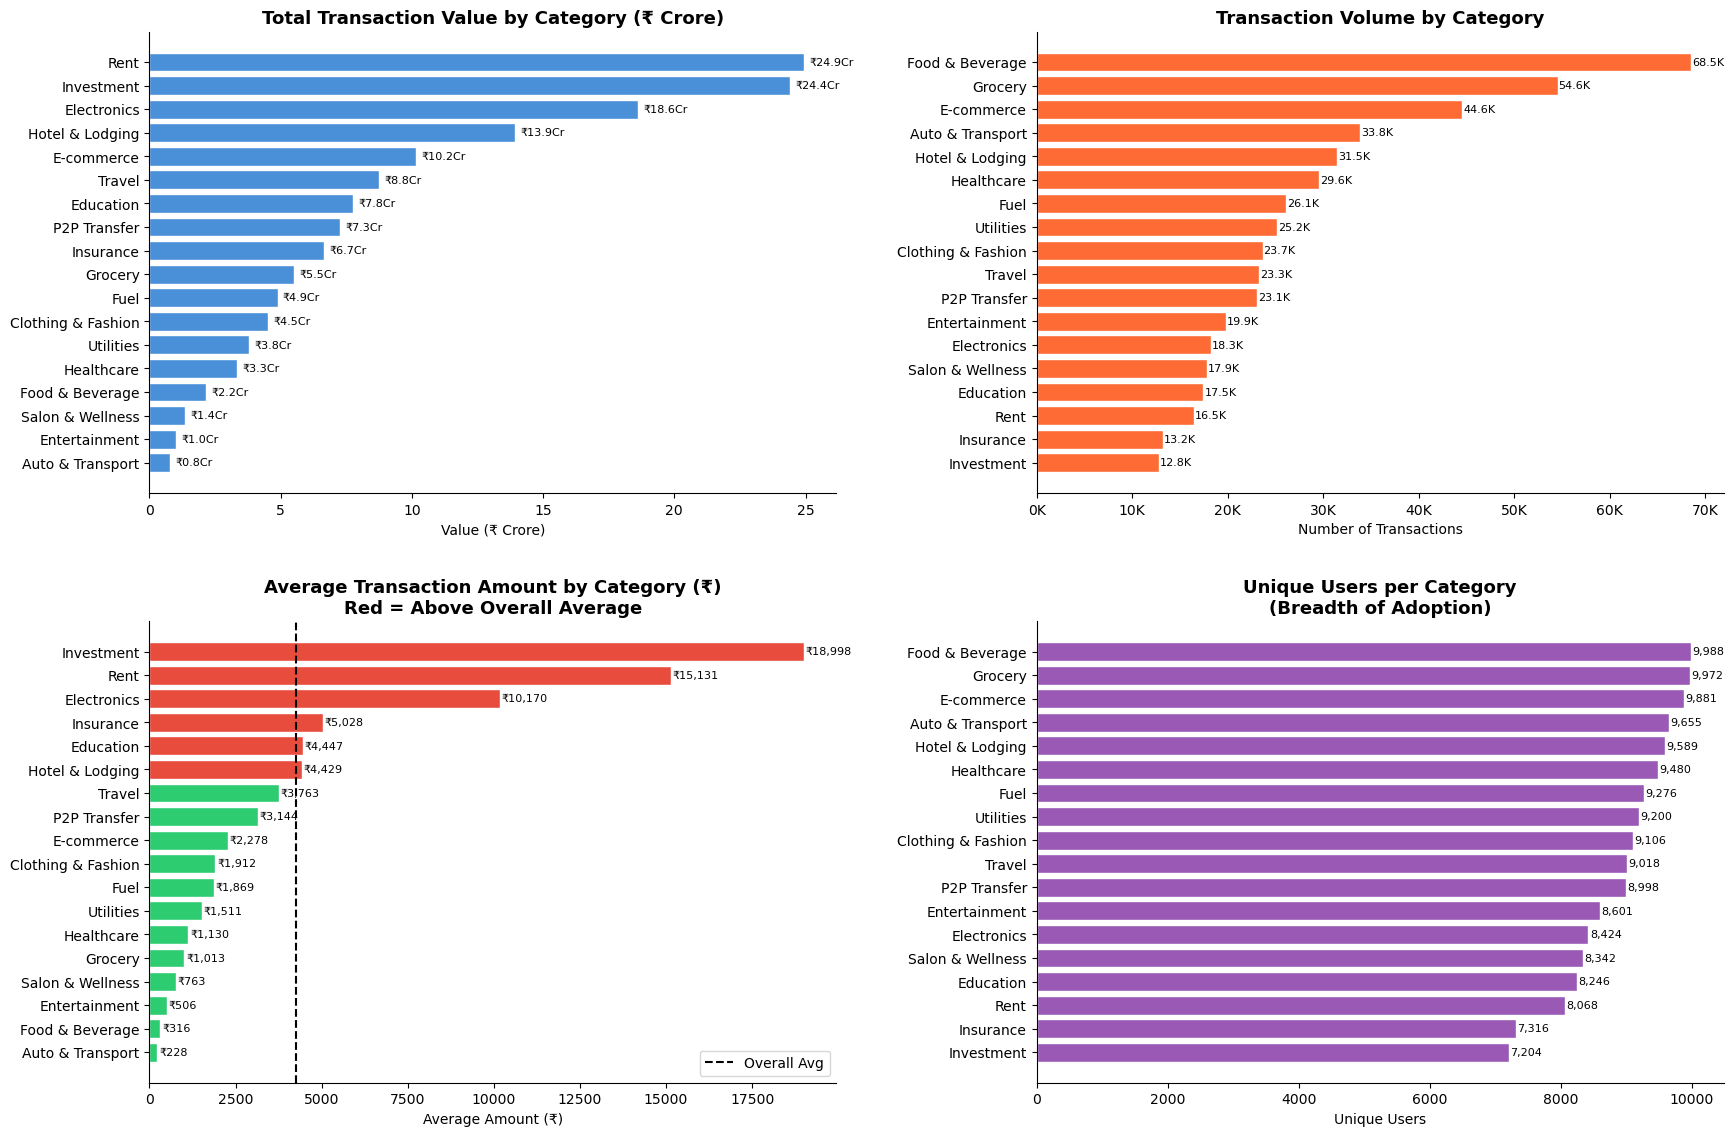

BUSINESS INSIGHT — MERCHANT CATEGORY
Highest Value Category:   Rent (₹24.9 Cr)
Highest Volume Category:  Food & Beverage (68,520 transactions)
Highest Avg Ticket:       Investment at ₹18,998
Lowest Avg Ticket:        Auto & Transport at ₹228
Widest User Adoption:     Food & Beverage (9,988 unique users)

Top 5 Categories by Value:
merchant_category  value_share  txn_share  avg_amount
             Rent         16.6        3.3     15131.0
       Investment         16.3        2.6     18998.0
      Electronics         12.4        3.7     10170.0
  Hotel & Lodging          9.3        6.3      4429.0
       E-commerce          6.8        8.9      2278.0


In [6]:
# ── Category level analysis ────────────────────────────────
category = df.groupby('merchant_category').agg(
    txn_count    = ('txn_id', 'count'),
    total_value  = ('amount', 'sum'),
    avg_amount   = ('amount', 'mean'),
    unique_users = ('user_id', 'nunique'),
    success_rate = ('is_success', 'mean'),
    fraud_rate   = ('is_fraud', 'mean')
).reset_index().sort_values('total_value', ascending=False)

category['txn_share']    = (category['txn_count'] / category['txn_count'].sum() * 100).round(1)
category['value_share']  = (category['total_value'] / category['total_value'].sum() * 100).round(1)
category['success_rate'] = (category['success_rate'] * 100).round(1)
category['fraud_rate']   = (category['fraud_rate'] * 100).round(3)
category['avg_amount']   = category['avg_amount'].round(0)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Plot 1: Total Value by Category ───────────────────────
cat_sorted_value = category.sort_values('total_value', ascending=True)
axes[0,0].barh(
    cat_sorted_value['merchant_category'],
    cat_sorted_value['total_value']/1e7,
    color='#4A90D9', edgecolor='white'
)
axes[0,0].set_title('Total Transaction Value by Category (₹ Crore)',
                     fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Value (₹ Crore)')
for i, (val, cat) in enumerate(zip(cat_sorted_value['total_value']/1e7,
                                    cat_sorted_value['merchant_category'])):
    axes[0,0].text(val + 0.2, i, f'₹{val:.1f}Cr', va='center', fontsize=8)

# ── Plot 2: Transaction Volume by Category ────────────────
cat_sorted_vol = category.sort_values('txn_count', ascending=True)
axes[0,1].barh(
    cat_sorted_vol['merchant_category'],
    cat_sorted_vol['txn_count'],
    color='#FF6B35', edgecolor='white'
)
axes[0,1].set_title('Transaction Volume by Category',
                     fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Number of Transactions')
axes[0,1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)
for i, val in enumerate(cat_sorted_vol['txn_count']):
    axes[0,1].text(val + 100, i, f'{val/1000:.1f}K', va='center', fontsize=8)

# ── Plot 3: Avg Transaction Amount by Category ────────────
cat_sorted_avg = category.sort_values('avg_amount', ascending=True)
colors_avg = ['#E74C3C' if v > category['avg_amount'].mean() 
              else '#2ECC71' for v in cat_sorted_avg['avg_amount']]
axes[1,0].barh(
    cat_sorted_avg['merchant_category'],
    cat_sorted_avg['avg_amount'],
    color=colors_avg, edgecolor='white'
)
axes[1,0].set_title('Average Transaction Amount by Category (₹)\nRed = Above Overall Average',
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Average Amount (₹)')
axes[1,0].axvline(category['avg_amount'].mean(), color='black', 
                   linestyle='--', linewidth=1.5, label='Overall Avg')
axes[1,0].legend()
for i, val in enumerate(cat_sorted_avg['avg_amount']):
    axes[1,0].text(val + 50, i, f'₹{val:,.0f}', va='center', fontsize=8)

# ── Plot 4: Unique Users by Category ─────────────────────
cat_sorted_users = category.sort_values('unique_users', ascending=True)
axes[1,1].barh(
    cat_sorted_users['merchant_category'],
    cat_sorted_users['unique_users'],
    color='#9B59B6', edgecolor='white'
)
axes[1,1].set_title('Unique Users per Category\n(Breadth of Adoption)',
                     fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Unique Users')
for i, val in enumerate(cat_sorted_users['unique_users']):
    axes[1,1].text(val + 20, i, f'{val:,}', va='center', fontsize=8)

plt.tight_layout(pad=3)
plt.savefig(exports_path + r"\03_category_intelligence.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Business Insight ───────────────────────────────────────
print("=" * 60)
print("BUSINESS INSIGHT — MERCHANT CATEGORY")
print("=" * 60)
top_value    = category.iloc[0]
top_volume   = category.loc[category['txn_count'].idxmax()]
highest_avg  = category.loc[category['avg_amount'].idxmax()]
lowest_avg   = category.loc[category['avg_amount'].idxmin()]
most_users   = category.loc[category['unique_users'].idxmax()]

print(f"Highest Value Category:   {top_value['merchant_category']} (₹{top_value['total_value']/1e7:.1f} Cr)")
print(f"Highest Volume Category:  {top_volume['merchant_category']} ({top_volume['txn_count']:,} transactions)")
print(f"Highest Avg Ticket:       {highest_avg['merchant_category']} at ₹{highest_avg['avg_amount']:,.0f}")
print(f"Lowest Avg Ticket:        {lowest_avg['merchant_category']} at ₹{lowest_avg['avg_amount']:,.0f}")
print(f"Widest User Adoption:     {most_users['merchant_category']} ({most_users['unique_users']:,} unique users)")
print(f"\nTop 5 Categories by Value:")
print(category[['merchant_category','value_share','txn_share','avg_amount']]
      .head(5).to_string(index=False))

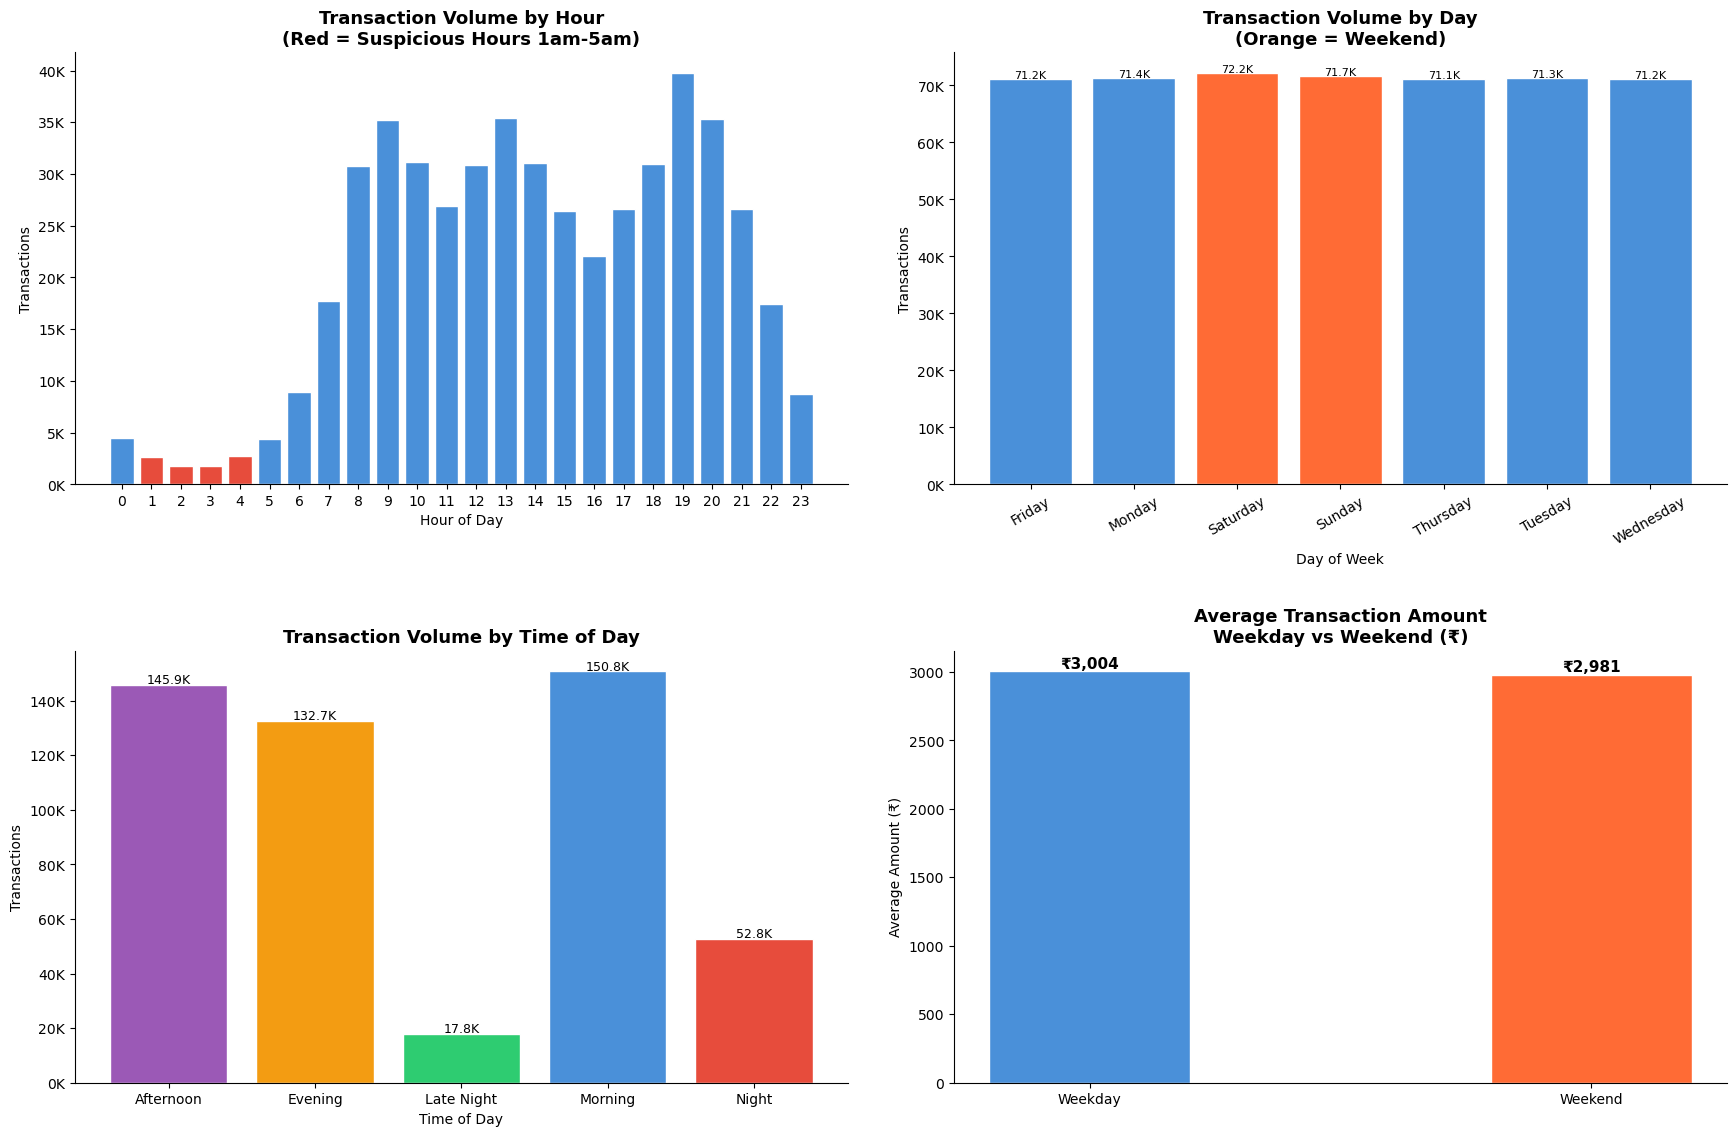

BUSINESS INSIGHT — TIME & BEHAVIORAL PATTERNS
Peak Hour:              19:00 (39,759.0 transactions)
Lowest Hour:            3:00 (1,778.0 transactions)
Peak Day:               Saturday (72,167 transactions)
Peak Time of Day:       Morning (150,764 transactions)
Suspicious Hour Txns:   8,959 transactions between 1am-5am
Weekend Avg Amount:     ₹2,981
Weekday Avg Amount:     ₹3,004
Weekend Lift:           -0.8% vs weekday


In [7]:
# ── Hour of day analysis ───────────────────────────────────
hourly = df.groupby('txn_hour').agg(
    txn_count   = ('txn_id', 'count'),
    total_value = ('amount', 'sum'),
    avg_amount  = ('amount', 'mean')
).reset_index()

# ── Day of week analysis ───────────────────────────────────
daily = df.groupby('day_of_week', observed=True).agg(
    txn_count   = ('txn_id', 'count'),
    total_value = ('amount', 'sum'),
    avg_amount  = ('amount', 'mean')
).reset_index()

# ── Time of day analysis ───────────────────────────────────
timeofday = df.groupby('time_of_day', observed=True).agg(
    txn_count   = ('txn_id', 'count'),
    total_value = ('amount', 'sum'),
    avg_amount  = ('amount', 'mean')
).reset_index()

# ── Weekend vs Weekday ────────────────────────────────────
weekend = df.groupby('is_weekend').agg(
    txn_count   = ('txn_id', 'count'),
    total_value = ('amount', 'sum'),
    avg_amount  = ('amount', 'mean')
).reset_index()
weekend['label'] = weekend['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Plot 1: Hourly Transaction Volume ─────────────────────
axes[0,0].bar(
    hourly['txn_hour'],
    hourly['txn_count'],
    color=['#E74C3C' if h in range(1,5) else '#4A90D9' for h in hourly['txn_hour']],
    edgecolor='white'
)
axes[0,0].set_title('Transaction Volume by Hour\n(Red = Suspicious Hours 1am-5am)',
                     fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Transactions')
axes[0,0].set_xticks(range(24))
axes[0,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)

# ── Plot 2: Day of Week Pattern ───────────────────────────
day_colors = ['#FF6B35' if d in ['Saturday','Sunday'] 
              else '#4A90D9' for d in daily['day_of_week']]
axes[0,1].bar(
    daily['day_of_week'],
    daily['txn_count'],
    color=day_colors, edgecolor='white'
)
axes[0,1].set_title('Transaction Volume by Day\n(Orange = Weekend)',
                     fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Day of Week')
axes[0,1].set_ylabel('Transactions')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)
for i, v in enumerate(daily['txn_count']):
    axes[0,1].text(i, v + 100, f'{v/1000:.1f}K', ha='center', fontsize=8)

# ── Plot 3: Time of Day Distribution ─────────────────────
tod_colors = ['#9B59B6', '#F39C12', '#2ECC71', '#4A90D9', '#E74C3C']
axes[1,0].bar(
    timeofday['time_of_day'],
    timeofday['txn_count'],
    color=tod_colors, edgecolor='white'
)
axes[1,0].set_title('Transaction Volume by Time of Day',
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Time of Day')
axes[1,0].set_ylabel('Transactions')
axes[1,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)
for i, v in enumerate(timeofday['txn_count']):
    axes[1,0].text(i, v + 500, f'{v/1000:.1f}K', ha='center', fontsize=9)

# ── Plot 4: Avg Amount — Weekday vs Weekend ───────────────
axes[1,1].bar(
    weekend['label'],
    weekend['avg_amount'],
    color=['#4A90D9', '#FF6B35'],
    edgecolor='white', width=0.4
)
axes[1,1].set_title('Average Transaction Amount\nWeekday vs Weekend (₹)',
                     fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Average Amount (₹)')
for i, v in enumerate(weekend['avg_amount']):
    axes[1,1].text(i, v + 20, f'₹{v:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(pad=3)
plt.savefig(exports_path + r"\04_time_behavioral_patterns.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Business Insight ───────────────────────────────────────
print("=" * 60)
print("BUSINESS INSIGHT — TIME & BEHAVIORAL PATTERNS")
print("=" * 60)
peak_hour    = hourly.loc[hourly['txn_count'].idxmax()]
lowest_hour  = hourly.loc[hourly['txn_count'].idxmin()]
peak_day     = daily.loc[daily['txn_count'].idxmax()]
peak_tod     = timeofday.loc[timeofday['txn_count'].idxmax()]
suspicious   = hourly[hourly['txn_hour'].isin(range(1,5))]['txn_count'].sum()
weekday_avg  = weekend[weekend['label']=='Weekday']['avg_amount'].values[0]
weekend_avg  = weekend[weekend['label']=='Weekend']['avg_amount'].values[0]
weekend_lift = ((weekend_avg - weekday_avg) / weekday_avg * 100)

print(f"Peak Hour:              {int(peak_hour['txn_hour'])}:00 ({peak_hour['txn_count']:,} transactions)")
print(f"Lowest Hour:            {int(lowest_hour['txn_hour'])}:00 ({lowest_hour['txn_count']:,} transactions)")
print(f"Peak Day:               {peak_day['day_of_week']} ({peak_day['txn_count']:,} transactions)")
print(f"Peak Time of Day:       {peak_tod['time_of_day']} ({peak_tod['txn_count']:,} transactions)")
print(f"Suspicious Hour Txns:   {suspicious:,} transactions between 1am-5am")
print(f"Weekend Avg Amount:     ₹{weekend_avg:,.0f}")
print(f"Weekday Avg Amount:     ₹{weekday_avg:,.0f}")
print(f"Weekend Lift:           {weekend_lift:+.1f}% vs weekday")

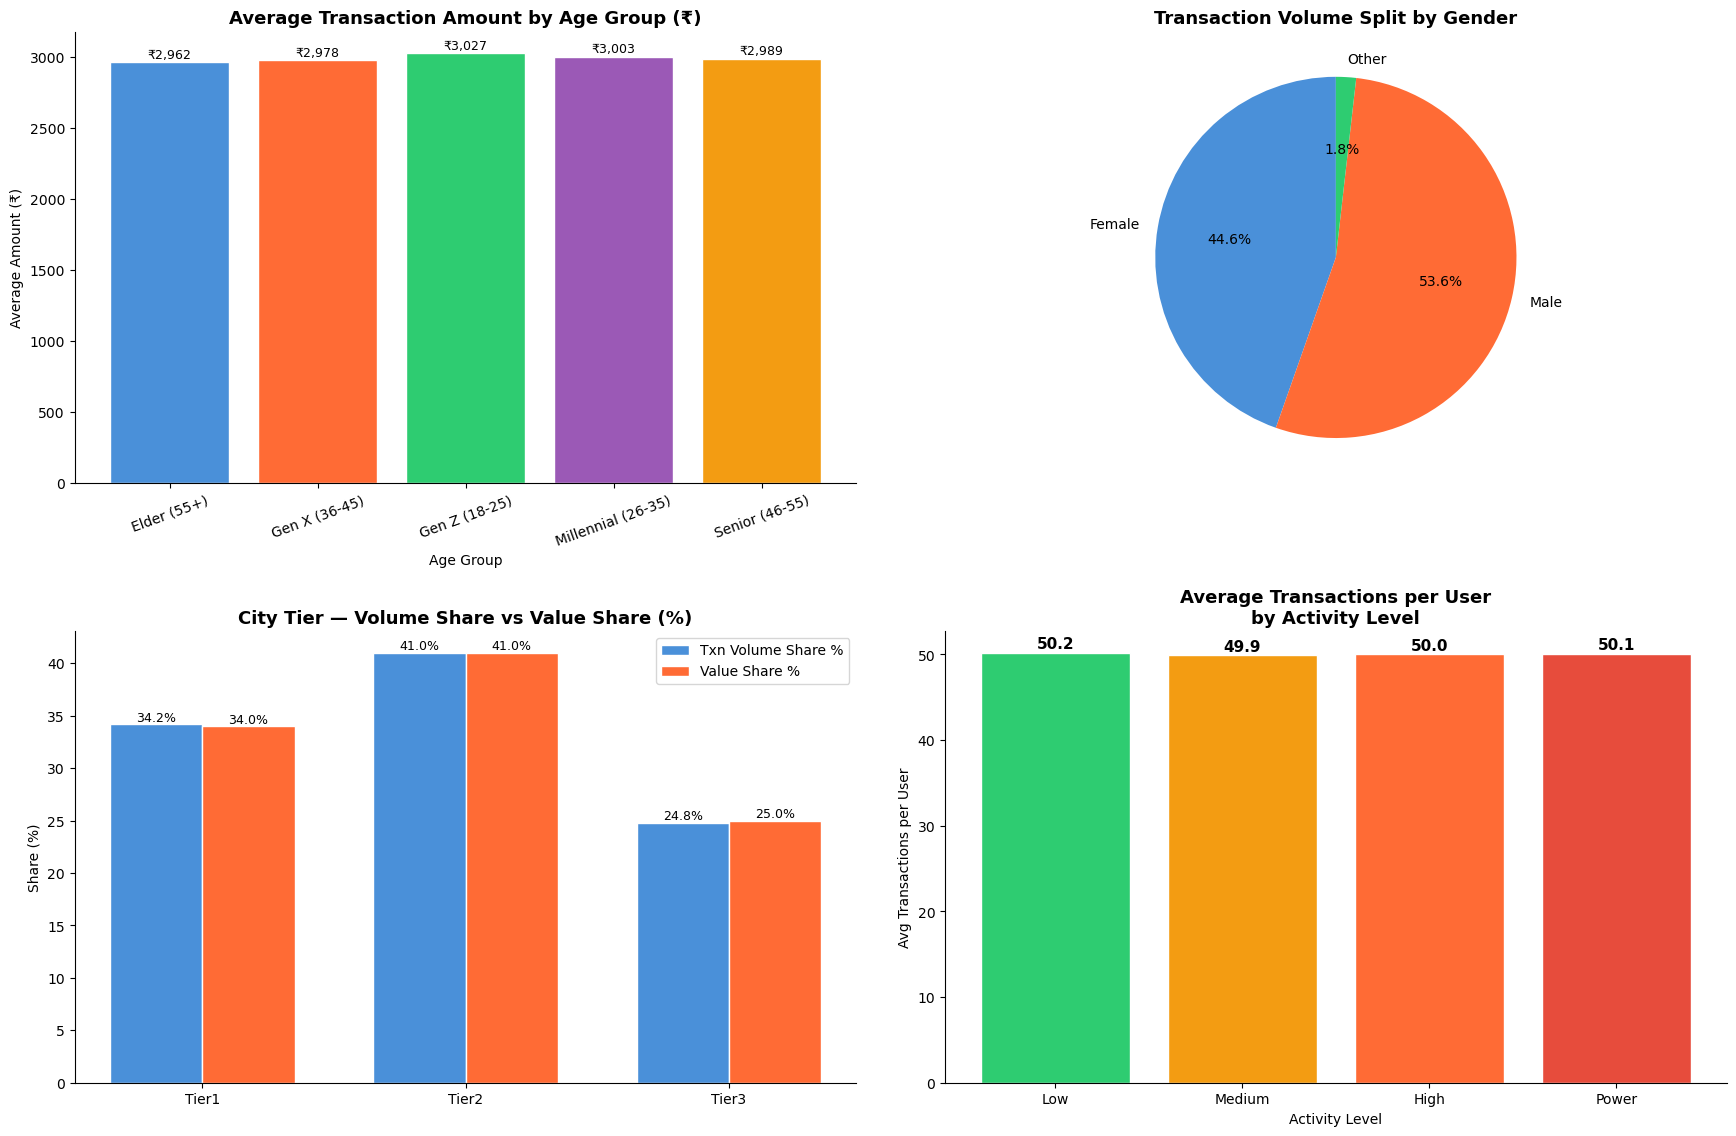

BUSINESS INSIGHT — USER DEMOGRAPHICS
Highest Value Age Group:  Millennial (26-35) (32.8% of total value)
Top City Tier by Value:   Tier2 (41.0% value share)

Activity Level Impact:
user_activity_level  unique_users  txn_per_user  value_share
                Low          2044          50.2         20.6
             Medium          4007          49.9         39.9
               High          2957          50.0         29.6
              Power           992          50.1          9.9

City Tier Breakdown:
user_city_tier  txn_share  value_share  avg_amount
         Tier1       34.2         34.0      2981.0
         Tier2       41.0         41.0      2994.0
         Tier3       24.8         25.0      3025.0

Gender Breakdown:
user_gender  txn_count  avg_amount
     Female     223058      3007.0
       Male     267944      2989.0
      Other       8998      3002.0


In [8]:
# ── Age group analysis ─────────────────────────────────────
age_group = df.groupby('age_group', observed=True).agg(
    txn_count   = ('txn_id', 'count'),
    total_value = ('amount', 'sum'),
    avg_amount  = ('amount', 'mean'),
    unique_users = ('user_id', 'nunique')
).reset_index()
age_group['avg_amount'] = age_group['avg_amount'].round(0)
age_group['value_share'] = (age_group['total_value'] / age_group['total_value'].sum() * 100).round(1)

# ── Gender analysis ────────────────────────────────────────
gender = df.groupby('user_gender').agg(
    txn_count   = ('txn_id', 'count'),
    total_value = ('amount', 'sum'),
    avg_amount  = ('amount', 'mean'),
    unique_users = ('user_id', 'nunique')
).reset_index()
gender['avg_amount'] = gender['avg_amount'].round(0)

# ── City tier analysis ─────────────────────────────────────
tier = df.groupby('user_city_tier').agg(
    txn_count   = ('txn_id', 'count'),
    total_value = ('amount', 'sum'),
    avg_amount  = ('amount', 'mean'),
    unique_users = ('user_id', 'nunique')
).reset_index()
tier['avg_amount']   = tier['avg_amount'].round(0)
tier['value_share']  = (tier['total_value'] / tier['total_value'].sum() * 100).round(1)
tier['txn_share']    = (tier['txn_count'] / tier['txn_count'].sum() * 100).round(1)

# ── Activity level analysis ────────────────────────────────
activity = df.groupby('user_activity_level').agg(
    txn_count   = ('txn_id', 'count'),
    total_value = ('amount', 'sum'),
    avg_amount  = ('amount', 'mean'),
    unique_users = ('user_id', 'nunique')
).reset_index()
activity['avg_amount']   = activity['avg_amount'].round(0)
activity['value_share']  = (activity['total_value'] / activity['total_value'].sum() * 100).round(1)
activity['txn_per_user'] = (activity['txn_count'] / activity['unique_users']).round(1)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Plot 1: Avg Amount by Age Group ───────────────────────
colors_age = ['#4A90D9','#FF6B35','#2ECC71','#9B59B6','#F39C12']
axes[0,0].bar(
    age_group['age_group'],
    age_group['avg_amount'],
    color=colors_age, edgecolor='white'
)
axes[0,0].set_title('Average Transaction Amount by Age Group (₹)',
                     fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Age Group')
axes[0,0].set_ylabel('Average Amount (₹)')
axes[0,0].tick_params(axis='x', rotation=20)
for i, v in enumerate(age_group['avg_amount']):
    axes[0,0].text(i, v + 30, f'₹{v:,.0f}', ha='center', fontsize=9)

# ── Plot 2: Gender Split ───────────────────────────────────
wedges, texts, autotexts = axes[0,1].pie(
    gender['txn_count'],
    labels=gender['user_gender'],
    autopct='%1.1f%%',
    colors=['#4A90D9','#FF6B35','#2ECC71'],
    startangle=90
)
for text in autotexts:
    text.set_fontsize(10)
axes[0,1].set_title('Transaction Volume Split by Gender',
                     fontsize=13, fontweight='bold')

# ── Plot 3: City Tier Comparison ──────────────────────────
x = np.arange(len(tier))
width = 0.35
bars1 = axes[1,0].bar(x - width/2, tier['txn_share'], width,
                       label='Txn Volume Share %', color='#4A90D9', edgecolor='white')
bars2 = axes[1,0].bar(x + width/2, tier['value_share'], width,
                       label='Value Share %', color='#FF6B35', edgecolor='white')
axes[1,0].set_title('City Tier — Volume Share vs Value Share (%)',
                     fontsize=13, fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(tier['user_city_tier'])
axes[1,0].set_ylabel('Share (%)')
axes[1,0].legend()
for bar in bars1:
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars2:
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{bar.get_height():.1f}%', ha='center', fontsize=9)

# ── Plot 4: Activity Level — Txns per User ────────────────
activity_order = ['Low', 'Medium', 'High', 'Power']
activity = activity.set_index('user_activity_level').reindex(activity_order).reset_index()
axes[1,1].bar(
    activity['user_activity_level'],
    activity['txn_per_user'],
    color=['#2ECC71','#F39C12','#FF6B35','#E74C3C'],
    edgecolor='white'
)
axes[1,1].set_title('Average Transactions per User\nby Activity Level',
                     fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Activity Level')
axes[1,1].set_ylabel('Avg Transactions per User')
for i, v in enumerate(activity['txn_per_user']):
    axes[1,1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(pad=3)
plt.savefig(exports_path + r"\05_user_demographics.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Business Insight ───────────────────────────────────────
print("=" * 60)
print("BUSINESS INSIGHT — USER DEMOGRAPHICS")
print("=" * 60)
top_age      = age_group.loc[age_group['value_share'].idxmax()]
top_tier     = tier.loc[tier['value_share'].idxmax()]
power_users  = activity[activity['user_activity_level'] == 'Power']
low_users    = activity[activity['user_activity_level'] == 'Low']

print(f"Highest Value Age Group:  {top_age['age_group']} ({top_age['value_share']}% of total value)")
print(f"Top City Tier by Value:   {top_tier['user_city_tier']} ({top_tier['value_share']}% value share)")
print(f"\nActivity Level Impact:")
print(activity[['user_activity_level','unique_users','txn_per_user','value_share']].to_string(index=False))
print(f"\nCity Tier Breakdown:")
print(tier[['user_city_tier','txn_share','value_share','avg_amount']].to_string(index=False))
print(f"\nGender Breakdown:")
print(gender[['user_gender','txn_count','avg_amount']].to_string(index=False))

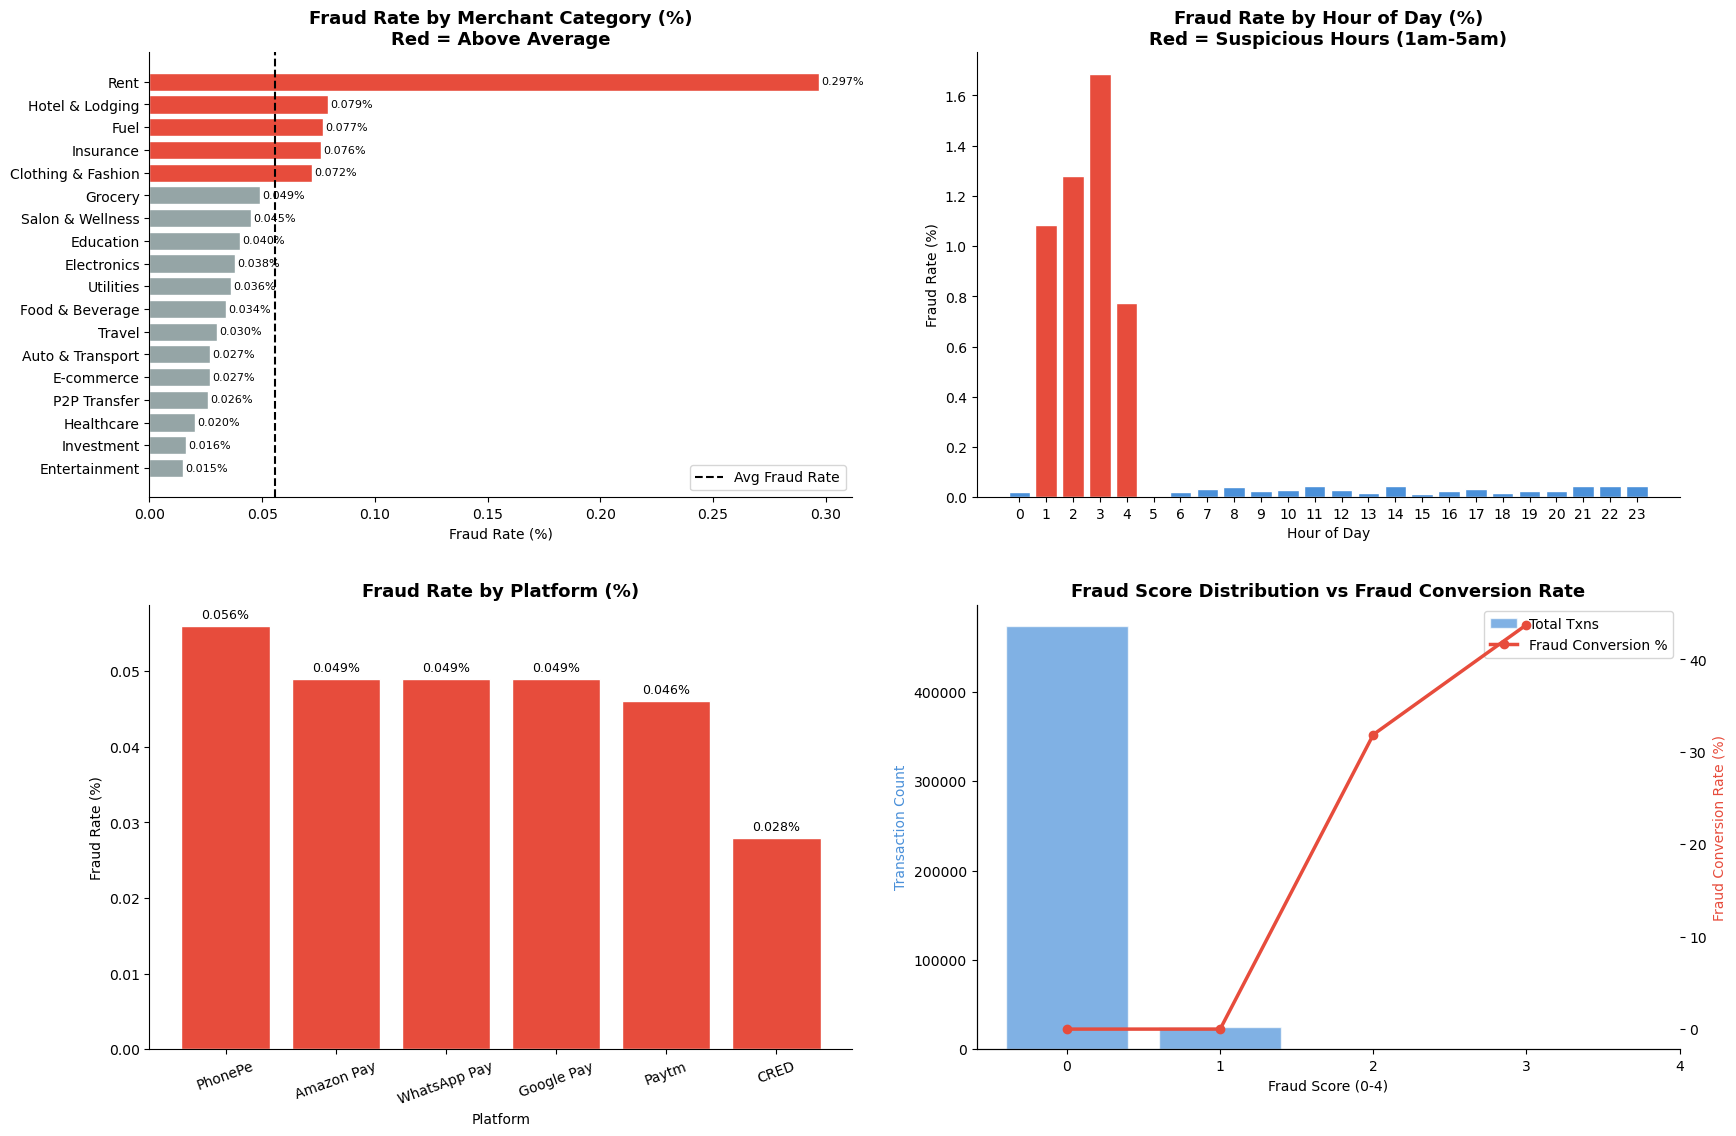

BUSINESS INSIGHT — FRAUD SIGNALS
Total Fraud Cases:         247 (0.049%)
Total Fraud Value:         ₹4,149,942
Avg Fraud Txn Amount:      ₹16,801
Highest Risk Category:     Rent (0.297%)
Suspicious Hour Fraud Rate:1.207% vs 0.029% normal hours
Highest Risk Platform:     PhonePe (0.056%)
High Risk Score (3+) Txns: 7 transactions flagged

Fraud Score Breakdown:
 fraud_score  txn_count  fraud_txns  fraud_conversion
           0     473864           0              0.00
           1      25367           0              0.00
           2        753         240             31.87
           3         16           7             43.75


In [9]:
# ── Fraud overview ─────────────────────────────────────────
fraud_df = df[df['is_fraud'] == 1].copy()
clean_df = df[df['is_fraud'] == 0].copy()

# ── Fraud by category ─────────────────────────────────────
fraud_cat = df.groupby('merchant_category').agg(
    total_txns  = ('txn_id', 'count'),
    fraud_txns  = ('is_fraud', 'sum'),
    fraud_amt   = ('amount', lambda x: x[df.loc[x.index, 'is_fraud']==1].sum())
).reset_index()
fraud_cat['fraud_rate'] = (fraud_cat['fraud_txns'] / fraud_cat['total_txns'] * 100).round(3)
fraud_cat = fraud_cat.sort_values('fraud_rate', ascending=False)

# ── Fraud by hour ──────────────────────────────────────────
fraud_hour = df.groupby('txn_hour').agg(
    total_txns = ('txn_id', 'count'),
    fraud_txns = ('is_fraud', 'sum')
).reset_index()
fraud_hour['fraud_rate'] = (fraud_hour['fraud_txns'] / fraud_hour['total_txns'] * 100).round(3)

# ── Fraud by platform ──────────────────────────────────────
fraud_platform = df.groupby('platform_used').agg(
    total_txns = ('txn_id', 'count'),
    fraud_txns = ('is_fraud', 'sum'),
    avg_fraud_amount = ('amount', lambda x: x[df.loc[x.index,'is_fraud']==1].mean())
).reset_index()
fraud_platform['fraud_rate'] = (fraud_platform['fraud_txns'] / fraud_platform['total_txns'] * 100).round(3)
fraud_platform = fraud_platform.sort_values('fraud_rate', ascending=False)

# ── Fraud score distribution ───────────────────────────────
fraud_score_dist = df.groupby('fraud_score').agg(
    txn_count  = ('txn_id', 'count'),
    fraud_txns = ('is_fraud', 'sum')
).reset_index()
fraud_score_dist['fraud_conversion'] = (
    fraud_score_dist['fraud_txns'] / fraud_score_dist['txn_count'] * 100
).round(2)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Plot 1: Fraud Rate by Category ────────────────────────
cat_sorted = fraud_cat.sort_values('fraud_rate', ascending=True)
colors_fraud = ['#E74C3C' if v > fraud_cat['fraud_rate'].mean() 
                else '#95A5A6' for v in cat_sorted['fraud_rate']]
axes[0,0].barh(
    cat_sorted['merchant_category'],
    cat_sorted['fraud_rate'],
    color=colors_fraud, edgecolor='white'
)
axes[0,0].axvline(fraud_cat['fraud_rate'].mean(), color='black',
                   linestyle='--', linewidth=1.5, label='Avg Fraud Rate')
axes[0,0].set_title('Fraud Rate by Merchant Category (%)\nRed = Above Average',
                     fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Fraud Rate (%)')
axes[0,0].legend()
for i, v in enumerate(cat_sorted['fraud_rate']):
    axes[0,0].text(v + 0.001, i, f'{v:.3f}%', va='center', fontsize=8)

# ── Plot 2: Fraud Rate by Hour ────────────────────────────
axes[0,1].bar(
    fraud_hour['txn_hour'],
    fraud_hour['fraud_rate'],
    color=['#E74C3C' if h in range(1,5) else '#4A90D9' for h in fraud_hour['txn_hour']],
    edgecolor='white'
)
axes[0,1].set_title('Fraud Rate by Hour of Day (%)\nRed = Suspicious Hours (1am-5am)',
                     fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Fraud Rate (%)')
axes[0,1].set_xticks(range(24))

# ── Plot 3: Fraud Rate by Platform ────────────────────────
axes[1,0].bar(
    fraud_platform['platform_used'],
    fraud_platform['fraud_rate'],
    color='#E74C3C', edgecolor='white'
)
axes[1,0].set_title('Fraud Rate by Platform (%)',
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Platform')
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].tick_params(axis='x', rotation=20)
for i, v in enumerate(fraud_platform['fraud_rate']):
    axes[1,0].text(i, v + 0.001, f'{v:.3f}%', ha='center', fontsize=9)

# ── Plot 4: Fraud Score vs Fraud Conversion ───────────────
ax2 = axes[1,1].twinx()
axes[1,1].bar(
    fraud_score_dist['fraud_score'],
    fraud_score_dist['txn_count'],
    color='#4A90D9', edgecolor='white', alpha=0.7, label='Total Txns'
)
ax2.plot(
    fraud_score_dist['fraud_score'],
    fraud_score_dist['fraud_conversion'],
    color='#E74C3C', marker='o', linewidth=2.5, label='Fraud Conversion %'
)
axes[1,1].set_title('Fraud Score Distribution vs Fraud Conversion Rate',
                     fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Fraud Score (0-4)')
axes[1,1].set_ylabel('Transaction Count', color='#4A90D9')
ax2.set_ylabel('Fraud Conversion Rate (%)', color='#E74C3C')
axes[1,1].set_xticks([0,1,2,3,4])
lines1, labels1 = axes[1,1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1,1].legend(lines1+lines2, labels1+labels2, loc='upper right')

plt.tight_layout(pad=3)
plt.savefig(exports_path + r"\06_fraud_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Business Insight ───────────────────────────────────────
print("=" * 60)
print("BUSINESS INSIGHT — FRAUD SIGNALS")
print("=" * 60)
highest_fraud_cat  = fraud_cat.iloc[0]
suspicious_hrs     = fraud_hour[fraud_hour['txn_hour'].isin(range(1,5))]['fraud_rate'].mean()
normal_hrs         = fraud_hour[~fraud_hour['txn_hour'].isin(range(1,5))]['fraud_rate'].mean()
highest_fraud_plat = fraud_platform.iloc[0]
score3_plus        = fraud_score_dist[fraud_score_dist['fraud_score'] >= 3]['fraud_txns'].sum()

print(f"Total Fraud Cases:         {df['is_fraud'].sum():,} ({df['is_fraud'].mean()*100:.3f}%)")
print(f"Total Fraud Value:         ₹{fraud_df['amount'].sum():,.0f}")
print(f"Avg Fraud Txn Amount:      ₹{fraud_df['amount'].mean():,.0f}")
print(f"Highest Risk Category:     {highest_fraud_cat['merchant_category']} ({highest_fraud_cat['fraud_rate']:.3f}%)")
print(f"Suspicious Hour Fraud Rate:{suspicious_hrs:.3f}% vs {normal_hrs:.3f}% normal hours")
print(f"Highest Risk Platform:     {highest_fraud_plat['platform_used']} ({highest_fraud_plat['fraud_rate']:.3f}%)")
print(f"High Risk Score (3+) Txns: {score3_plus:,} transactions flagged")
print(f"\nFraud Score Breakdown:")
print(fraud_score_dist.to_string(index=False))

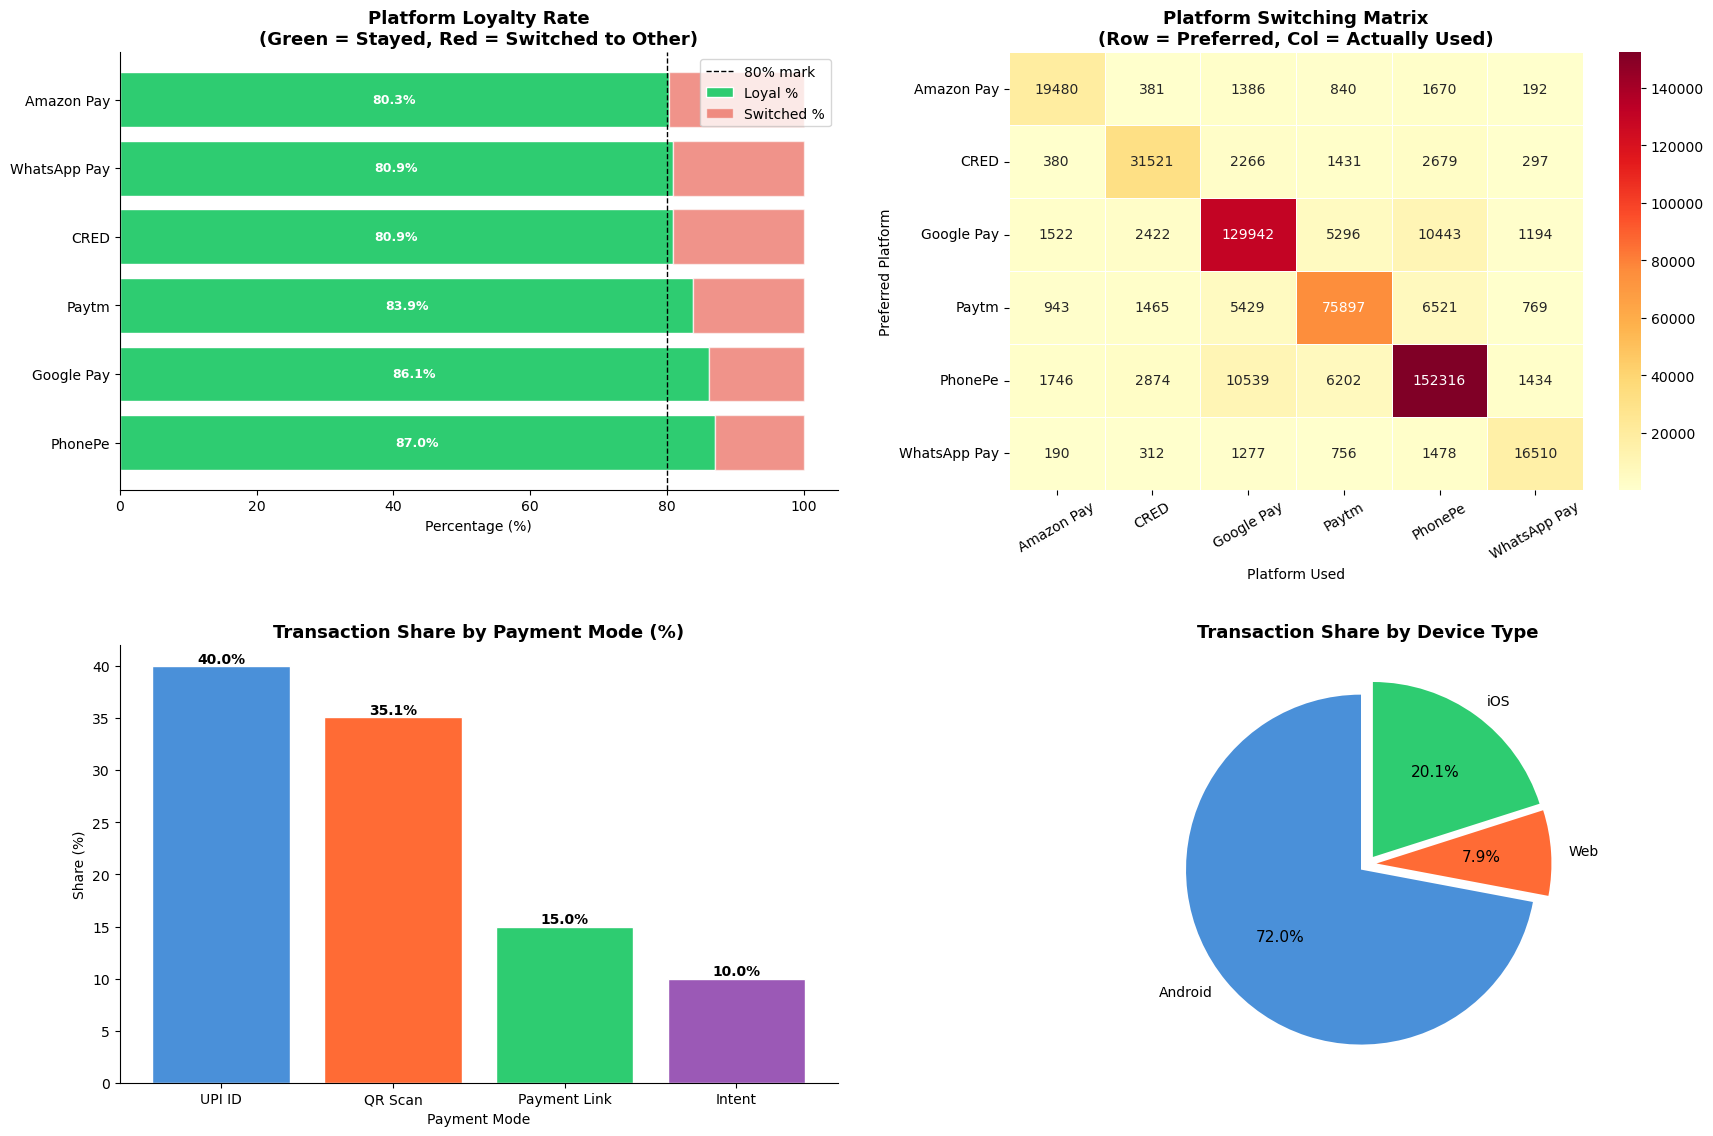

BUSINESS INSIGHT — PLATFORM STICKINESS
Most Loyal Platform:    PhonePe (87.0% users stay)
Least Loyal Platform:   Amazon Pay (80.3% users stay)

Payment Mode Breakdown:
payment_mode  txn_share  avg_amount  success_rate
      UPI ID       40.0      2996.0          91.0
     QR Scan       35.1      3002.0          90.9
Payment Link       15.0      2978.0          91.1
      Intent       10.0      3015.0          91.0

Device Type Breakdown:
device_type  txn_share  avg_amount  success_rate  fraud_rate
    Android       72.0      2993.0          90.9       0.049
        Web        7.9      3014.0          91.4       0.058
        iOS       20.1      3005.0          90.9       0.048

Platform Loyalty Summary:
platform_used  loyalty_rate  total_txns  unique_users
      PhonePe          87.0      175107          9827
   Google Pay          86.1      150839          9680
        Paytm          83.9       90422          8614
         CRED          80.9       38975          5868
 WhatsApp Pay   

In [10]:
# ── Platform loyalty analysis ──────────────────────────────
loyalty = df.groupby('platform_used').agg(
    total_txns          = ('txn_id', 'count'),
    preferred_txns      = ('is_preferred_platform', 'sum'),
    unique_users        = ('user_id', 'nunique')
).reset_index()
loyalty['loyalty_rate'] = (loyalty['preferred_txns'] / loyalty['total_txns'] * 100).round(1)
loyalty['non_loyal']    = 100 - loyalty['loyalty_rate']
loyalty = loyalty.sort_values('loyalty_rate', ascending=False)

# ── Cross platform usage ───────────────────────────────────
cross = df.groupby(['preferred_platform', 'platform_used']).agg(
    txn_count = ('txn_id', 'count')
).reset_index()

cross_pivot = cross.pivot(
    index='preferred_platform',
    columns='platform_used',
    values='txn_count'
).fillna(0)

# ── Payment mode analysis ──────────────────────────────────
paymode = df.groupby('payment_mode').agg(
    txn_count   = ('txn_id', 'count'),
    avg_amount  = ('amount', 'mean'),
    success_rate = ('is_success', 'mean'),
    fraud_rate  = ('is_fraud', 'mean')
).reset_index()
paymode['txn_share']     = (paymode['txn_count'] / paymode['txn_count'].sum() * 100).round(1)
paymode['success_rate']  = (paymode['success_rate'] * 100).round(1)
paymode['fraud_rate']    = (paymode['fraud_rate'] * 100).round(3)
paymode['avg_amount']    = paymode['avg_amount'].round(0)
paymode = paymode.sort_values('txn_count', ascending=False)

# ── Device type analysis ───────────────────────────────────
device = df.groupby('device_type').agg(
    txn_count   = ('txn_id', 'count'),
    avg_amount  = ('amount', 'mean'),
    success_rate = ('is_success', 'mean'),
    fraud_rate  = ('is_fraud', 'mean')
).reset_index()
device['txn_share']    = (device['txn_count'] / device['txn_count'].sum() * 100).round(1)
device['success_rate'] = (device['success_rate'] * 100).round(1)
device['fraud_rate']   = (device['fraud_rate'] * 100).round(3)
device['avg_amount']   = device['avg_amount'].round(0)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Plot 1: Platform Loyalty Rate ─────────────────────────
axes[0,0].barh(
    loyalty['platform_used'],
    loyalty['loyalty_rate'],
    color='#2ECC71', edgecolor='white', label='Loyal %'
)
axes[0,0].barh(
    loyalty['platform_used'],
    loyalty['non_loyal'],
    left=loyalty['loyalty_rate'],
    color='#E74C3C', edgecolor='white', alpha=0.6, label='Switched %'
)
axes[0,0].set_title('Platform Loyalty Rate\n(Green = Stayed, Red = Switched to Other)',
                     fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Percentage (%)')
axes[0,0].axvline(80, color='black', linestyle='--', linewidth=1, label='80% mark')
axes[0,0].legend()
for i, v in enumerate(loyalty['loyalty_rate']):
    axes[0,0].text(v/2, i, f'{v}%', ha='center', va='center',
                   fontsize=9, fontweight='bold', color='white')

# ── Plot 2: Platform Switching Heatmap ────────────────────
sns.heatmap(
    cross_pivot,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    ax=axes[0,1],
    linewidths=0.5
)
axes[0,1].set_title('Platform Switching Matrix\n(Row = Preferred, Col = Actually Used)',
                     fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Platform Used')
axes[0,1].set_ylabel('Preferred Platform')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].tick_params(axis='y', rotation=0)

# ── Plot 3: Payment Mode Analysis ─────────────────────────
colors_mode = ['#4A90D9','#FF6B35','#2ECC71','#9B59B6']
axes[1,0].bar(
    paymode['payment_mode'],
    paymode['txn_share'],
    color=colors_mode, edgecolor='white'
)
axes[1,0].set_title('Transaction Share by Payment Mode (%)',
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Payment Mode')
axes[1,0].set_ylabel('Share (%)')
for i, v in enumerate(paymode['txn_share']):
    axes[1,0].text(i, v + 0.3, f'{v}%', ha='center', fontsize=10, fontweight='bold')

# ── Plot 4: Device Type Breakdown ─────────────────────────
wedges, texts, autotexts = axes[1,1].pie(
    device['txn_count'],
    labels=device['device_type'],
    autopct='%1.1f%%',
    colors=['#4A90D9','#FF6B35','#2ECC71'],
    startangle=90,
    explode=[0.05, 0.05, 0.05]
)
for text in autotexts:
    text.set_fontsize(11)
axes[1,1].set_title('Transaction Share by Device Type',
                     fontsize=13, fontweight='bold')

plt.tight_layout(pad=3)
plt.savefig(exports_path + r"\07_platform_stickiness.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Business Insight ───────────────────────────────────────
print("=" * 60)
print("BUSINESS INSIGHT — PLATFORM STICKINESS")
print("=" * 60)
most_loyal   = loyalty.iloc[0]
least_loyal  = loyalty.iloc[-1]
top_mode     = paymode.iloc[0]
top_device   = device.loc[device['txn_count'].idxmax()]

print(f"Most Loyal Platform:    {most_loyal['platform_used']} ({most_loyal['loyalty_rate']}% users stay)")
print(f"Least Loyal Platform:   {least_loyal['platform_used']} ({least_loyal['loyalty_rate']}% users stay)")
print(f"\nPayment Mode Breakdown:")
print(paymode[['payment_mode','txn_share','avg_amount','success_rate']].to_string(index=False))
print(f"\nDevice Type Breakdown:")
print(device[['device_type','txn_share','avg_amount','success_rate','fraud_rate']].to_string(index=False))
print(f"\nPlatform Loyalty Summary:")
print(loyalty[['platform_used','loyalty_rate','total_txns','unique_users']].to_string(index=False))